  label                                               text  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                        processed_v2  
0  Go until jurong point, crazy.. Available only ...  
1                      Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup fina...  
3  U dun say so early hor... U c already then say...  
4  Nah I don't think he goes to usf, he lives aro...  
Baseline 1
Accuracy: 0.9730941704035875
Macro-F1: 0.9363845908074308

Baseline 2
Accuracy: 0.9820627802690582
Macro-F1: 0.9610455853992566


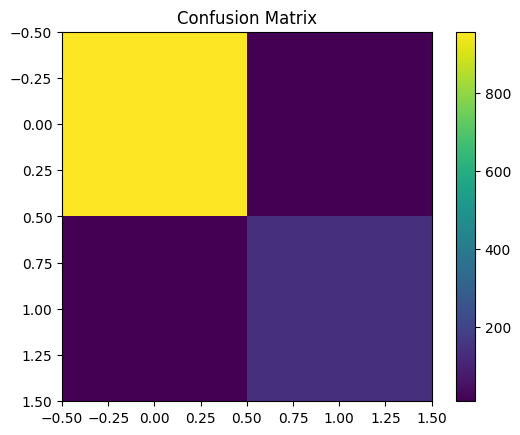


Top features for class SPAM:
['your', 'www', 'uk', 'reply', 'text', 'stop', 'to', 'free', 'txt', 'call']

Top features for class HAM:
['my', 'me', 'that', 'ok', 'it', 'but', 'll', 'gt', 'lt', 'come']

ERROR ANALYSIS:
                                           processed_v2 label  pred
417                       Alright i have a new goal now   ham  spam
5     FreeMsg Hey there darling it's been 3 week's n...  spam   ham
3981                                 ringtoneking 84484  spam   ham
3360  Sorry I missed your call let's talk when you h...  spam   ham
5449  Latest News! Police station toilet stolen, cop...  spam   ham
1460  Bought one ringtone and now getting texts cost...  spam   ham
700            K..u also dont msg or reply to his msg..   ham  spam
1269  Can U get 2 phone NOW? I wanna chat 2 set up m...  spam   ham
1430  For sale - arsenal dartboard. Good condition b...  spam   ham
1082                  Can u get pic msgs to your phone?   ham  spam


In [3]:
# =========================
# 1. INSTALL
# =========================
!pip install pandas scikit-learn matplotlib

# =========================
# 2. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# =========================
# 3. LOAD DATA
# =========================
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "text"])

# перетворимо під нашу лабу
df["processed_v2"] = df["text"]

# перевірка
print(df.head())

TEXT_COL = "processed_v2"
LABEL_COL = "label"

df = df[[TEXT_COL, LABEL_COL]].dropna()

# =========================
# 4. SPLIT
# =========================
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[LABEL_COL]
)

# =========================
# 5. BASELINE 1
# =========================
baseline_1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(max_iter=300))
])

baseline_1.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_1 = baseline_1.predict(test_df[TEXT_COL])

acc1 = accuracy_score(test_df[LABEL_COL], pred_1)
f1_1 = f1_score(test_df[LABEL_COL], pred_1, average="macro")

print("Baseline 1")
print("Accuracy:", acc1)
print("Macro-F1:", f1_1)

# =========================
# 6. BASELINE 2
# =========================
baseline_2 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=300, class_weight="balanced"))
])

baseline_2.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_2 = baseline_2.predict(test_df[TEXT_COL])

acc2 = accuracy_score(test_df[LABEL_COL], pred_2)
f1_2 = f1_score(test_df[LABEL_COL], pred_2, average="macro")

print("\nBaseline 2")
print("Accuracy:", acc2)
print("Macro-F1:", f1_2)

# =========================
# 7. CONFUSION MATRIX
# =========================
cm = confusion_matrix(test_df[LABEL_COL], pred_2)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

# =========================
# 8. TOP FEATURES
# =========================
vectorizer = baseline_2.named_steps["tfidf"]
model = baseline_2.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()

coefs = model.coef_[0]

# TOP для spam (позитивний клас)
top_spam = np.argsort(coefs)[-10:]

print("\nTop features for class SPAM:")
print([feature_names[i] for i in top_spam])

# TOP для ham (негативний клас)
top_ham = np.argsort(coefs)[:10]

print("\nTop features for class HAM:")
print([feature_names[i] for i in top_ham])

# =========================
# 9. ERROR ANALYSIS (10)
# =========================
errors = test_df.copy()
errors["pred"] = pred_2

errors = errors[errors[LABEL_COL] != errors["pred"]].head(10)

print("\nERROR ANALYSIS:")
print(errors)